In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as const

# import classy module
from classy import Class

### Generic comparison of different modes

In [3]:
standard_input = {
        'T_cmb':2.7255, #Temperature of CMB today
        'omega_b':2.255065e-02, #Baryon density today
        'omega_cdm':1.193524e-01, #Cold DM density today
        'H0':6.776953e+01, #Hubble Parameter today
        
        'A_s':2.123257e-09, #Primordial power spectrum amplitude
        'n_s':9.686025e-01, #Primordial spectral index
    
        # output quantities
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit', 
        'k_per_decade_primordial': 1000
}

cosmo_0 = Class()
cosmo_0.set(standard_input)

cosmo_1 = Class()
cosmo_1.set(standard_input)

cosmo_2 = Class()
cosmo_2.set(standard_input)

cosmo_3 = Class()
cosmo_3.set(standard_input)

# Set your custom parameters
cosmo_0.set({
        'P_k_ini type': 'analytic_Pk',
})
cosmo_0.compute()

cosmo_1.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'logarithmic',
        'A_gosc_cos': 0.1,
        'A_gosc_sin': 0.0,
        'omega_gosc': 10.0
})
cosmo_1.compute()

cosmo_2.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'linear',
        'A_gosc_cos': 0.1,
        'A_gosc_sin': 0.0,
        'omega_gosc': 10.0,
})
cosmo_2.compute()

cosmo_3.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'global',
        'osc_model_type': 'running_frequency',
        'A_gosc_cos': 0.1,
        'A_gosc_sin': 0.0,
        'omega_gosc': 10.0,
        'alpha_rf': 0.1
})
cosmo_3.compute()

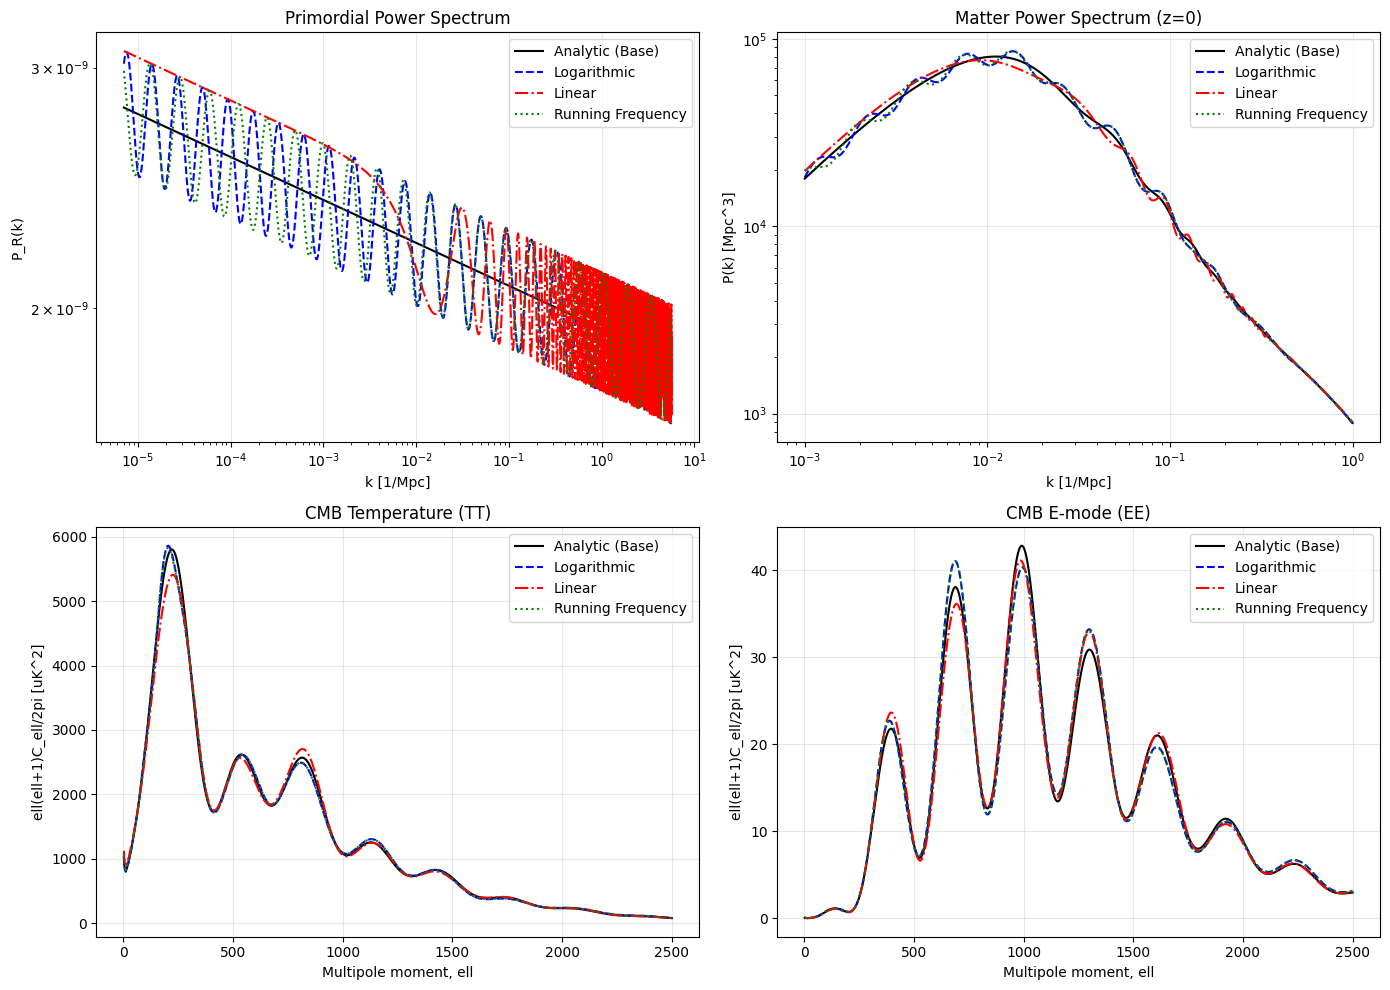

In [4]:
# Group the models for easy looping
models = [
    (cosmo_0, 'Analytic (Base)', 'black', '-'),
    (cosmo_1, 'Logarithmic', 'blue', '--'),
    (cosmo_2, 'Linear', 'red', '-.'),
    (cosmo_3, 'Running Frequency', 'green', ':')
]

# Set up the 2x2 plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Primordial Power Spectrum (Top Left)
ax[0, 0].set_title('Primordial Power Spectrum')
ax[0, 0].set_xlabel('k [1/Mpc]')
ax[0, 0].set_ylabel('P_R(k)')

# 2. Matter Power Spectrum Today (Top Right)
ax[0, 1].set_title('Matter Power Spectrum (z=0)')
ax[0, 1].set_xlabel('k [1/Mpc]')
ax[0, 1].set_ylabel('P(k) [Mpc^3]')
# Create a k-array based on your P_k_max limit (up to ~1 1/Mpc)
k_m = np.logspace(-3, 0, 400) 

# 3. CMB Temperature TT (Bottom Left)
ax[1, 0].set_title('CMB Temperature (TT)')
ax[1, 0].set_xlabel('Multipole moment, ell')
ax[1, 0].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# 4. CMB E-mode Polarization EE (Bottom Right)
ax[1, 1].set_title('CMB E-mode (EE)')
ax[1, 1].set_xlabel('Multipole moment, ell')
ax[1, 1].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# Extract data and plot for each model
T_cmb_uK = 2.7255e6 # CMB temp in micro-Kelvin

for cosmo, name, color, line in models:
    
    # --- Primordial Power Spectrum ---
    pps = cosmo.get_primordial()
    k_prim = pps['k [1/Mpc]']
    pk_prim = pps['P_scalar(k)']
    ax[0, 0].loglog(k_prim, pk_prim, label=name, color=color, linestyle=line)
    
    # --- Matter Power Spectrum ---
    # cosmo.pk(k, z) evaluates a single k-value, so we loop over the array
    pk_m = np.array([cosmo.pk(k, 0.0) for k in k_m])
    ax[0, 1].loglog(k_m, pk_m, label=name, color=color, linestyle=line)
    
    # --- CMB Spectra ---
    # Extract lensed Cls up to ell=2500
    cls = cosmo.lensed_cl(2500)
    ell = cls['ell'][2:] # Skip ell=0 and 1
    
    # Convert dimensionless Cls to standard uK^2 format
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    ax[1, 0].plot(ell, cl_tt, label=name, color=color, linestyle=line)
    ax[1, 1].plot(ell, cl_ee, label=name, color=color, linestyle=line)

# Clean up layout and add legends
for axis in ax.flat:
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("global_model_comparison_plots.png", bbox_inches='tight', dpi=300)
plt.show()

In [5]:
standard_input = {
        'T_cmb':2.7255, #Temperature of CMB today
        'omega_b':2.255065e-02, #Baryon density today
        'omega_cdm':1.193524e-01, #Cold DM density today
        'H0':6.776953e+01, #Hubble Parameter today
        
        'A_s':2.123257e-09, #Primordial power spectrum amplitude
        'n_s':9.686025e-01, #Primordial spectral index
    
        # output quantities
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit', 
        'k_per_decade_primordial': 1000
}

cosmo_0 = Class()
cosmo_0.set(standard_input)

cosmo_1 = Class()
cosmo_1.set(standard_input)

# Set your custom parameters
cosmo_0.set({
        'P_k_ini type': 'analytic_Pk',
})
cosmo_0.compute()

cosmo_1.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'local',
        'A_losc': 0.1,
        'k_losc': 0.01,
        'x_losc': 10.0
})
cosmo_1.compute()

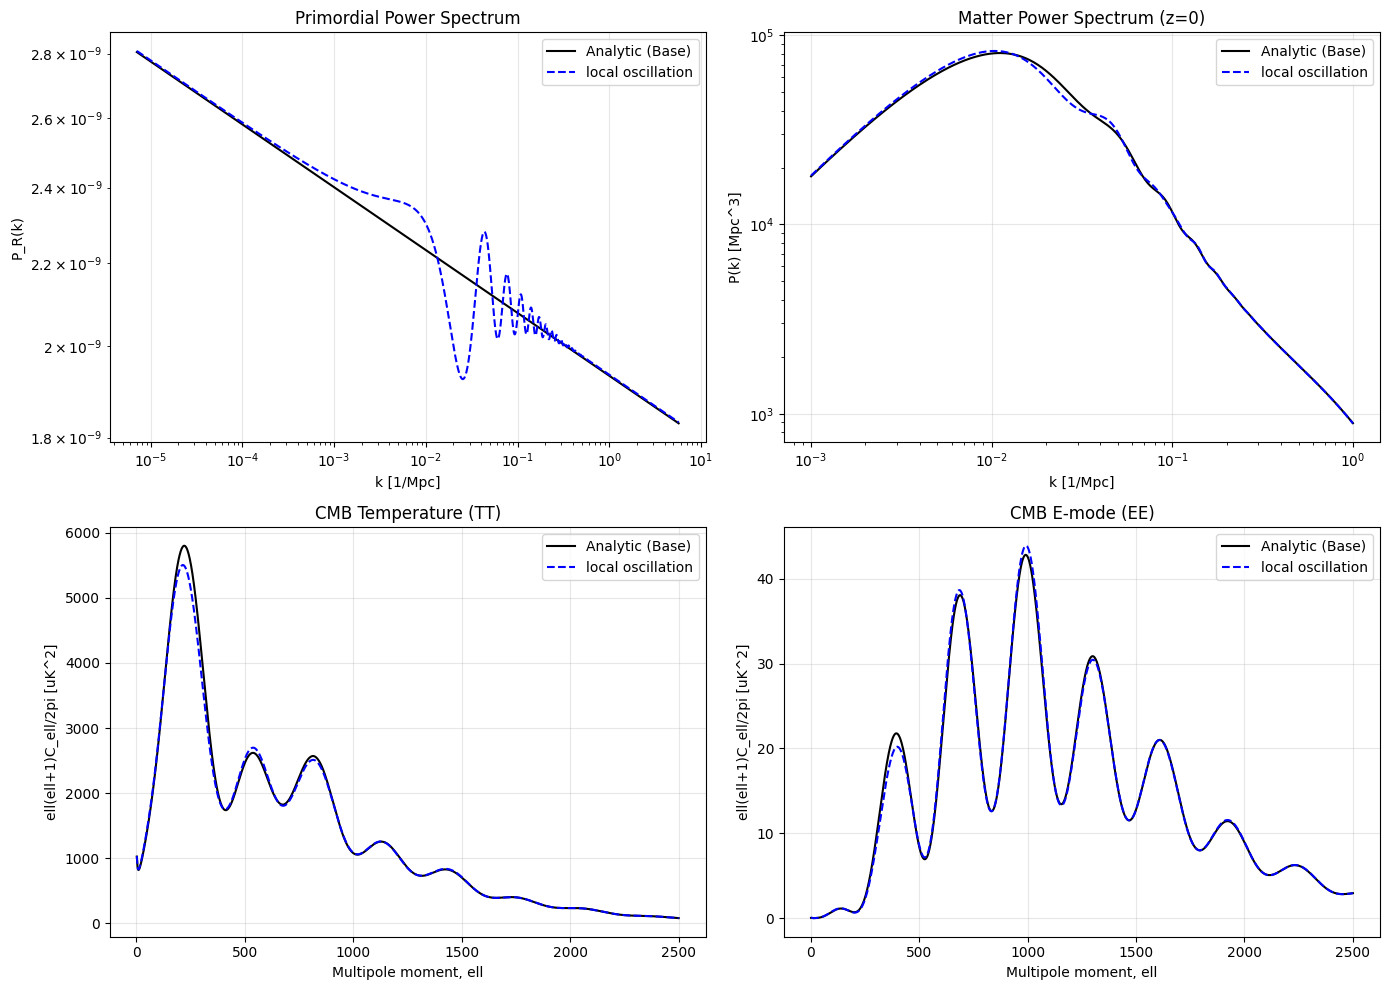

In [6]:
# Group the models for easy looping
models = [
    (cosmo_0, 'Analytic (Base)', 'black', '-'),
    (cosmo_1, 'local oscillation', 'blue', '--'),
]

# Set up the 2x2 plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Primordial Power Spectrum (Top Left)
ax[0, 0].set_title('Primordial Power Spectrum')
ax[0, 0].set_xlabel('k [1/Mpc]')
ax[0, 0].set_ylabel('P_R(k)')

# 2. Matter Power Spectrum Today (Top Right)
ax[0, 1].set_title('Matter Power Spectrum (z=0)')
ax[0, 1].set_xlabel('k [1/Mpc]')
ax[0, 1].set_ylabel('P(k) [Mpc^3]')
# Create a k-array based on your P_k_max limit (up to ~1 1/Mpc)
k_m = np.logspace(-3, 0, 400) 

# 3. CMB Temperature TT (Bottom Left)
ax[1, 0].set_title('CMB Temperature (TT)')
ax[1, 0].set_xlabel('Multipole moment, ell')
ax[1, 0].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# 4. CMB E-mode Polarization EE (Bottom Right)
ax[1, 1].set_title('CMB E-mode (EE)')
ax[1, 1].set_xlabel('Multipole moment, ell')
ax[1, 1].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# Extract data and plot for each model
T_cmb_uK = 2.7255e6 # CMB temp in micro-Kelvin

for cosmo, name, color, line in models:
    
    # --- Primordial Power Spectrum ---
    pps = cosmo.get_primordial()
    k_prim = pps['k [1/Mpc]']
    pk_prim = pps['P_scalar(k)']
    ax[0, 0].loglog(k_prim, pk_prim, label=name, color=color, linestyle=line)
    
    # --- Matter Power Spectrum ---
    # cosmo.pk(k, z) evaluates a single k-value, so we loop over the array
    pk_m = np.array([cosmo.pk(k, 0.0) for k in k_m])
    ax[0, 1].loglog(k_m, pk_m, label=name, color=color, linestyle=line)
    
    # --- CMB Spectra ---
    # Extract lensed Cls up to ell=2500
    cls = cosmo.lensed_cl(2500)
    ell = cls['ell'][2:] # Skip ell=0 and 1
    
    # Convert dimensionless Cls to standard uK^2 format
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    ax[1, 0].plot(ell, cl_tt, label=name, color=color, linestyle=line)
    ax[1, 1].plot(ell, cl_ee, label=name, color=color, linestyle=line)

# Clean up layout and add legends
for axis in ax.flat:
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("local_model_comparison_plots.png", bbox_inches='tight', dpi=300)
plt.show()

In [3]:
standard_input = {
        'T_cmb':2.7255, #Temperature of CMB today
        'omega_b':2.255065e-02, #Baryon density today
        'omega_cdm':1.193524e-01, #Cold DM density today
        'H0':6.776953e+01, #Hubble Parameter today
        
        'A_s':2.123257e-09, #Primordial power spectrum amplitude
        'n_s':9.686025e-01, #Primordial spectral index
    
        # output quantities
        'output':'mPk, tCl, pCl, lCl',
        'lensing':'yes',
        'P_k_max_h/Mpc':1.0,
        'non_linear':'halofit', 
        'k_per_decade_primordial': 1000
}

cosmo_0 = Class()
cosmo_0.set(standard_input)

cosmo_1 = Class()
cosmo_1.set(standard_input)

cosmo_2 = Class()
cosmo_2.set(standard_input)

cosmo_3 = Class()
cosmo_3.set(standard_input)

# Set your custom parameters
cosmo_0.set({
        'P_k_ini type': 'analytic_Pk',
})
cosmo_0.compute()

cosmo_1.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'axion',
        'A_ax_sin': 0.1,
        'A_ax_cos': 0.1,
        'f_ax_Mpl': 0.01,
        'p_f_ax': 0.25,
        'p_ax': 4/3
})
cosmo_1.compute()

cosmo_2.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'axion',
        'A_ax_sin': 0.1,
        'A_ax_cos': 0.1,
        'f_ax_Mpl': 0.01,
        'p_f_ax': 0.25,
        'p_ax': 1
})
cosmo_2.compute()

cosmo_3.set({
        'P_k_ini type': 'analytic_Pk',
        'modifications': 'axion',
        'A_ax_sin': 0.1,
        'A_ax_cos': 0.1,
        'f_ax_Mpl': 0.01,
        'p_f_ax': 0.25,
        'p_ax': 2/3
})
cosmo_3.compute()

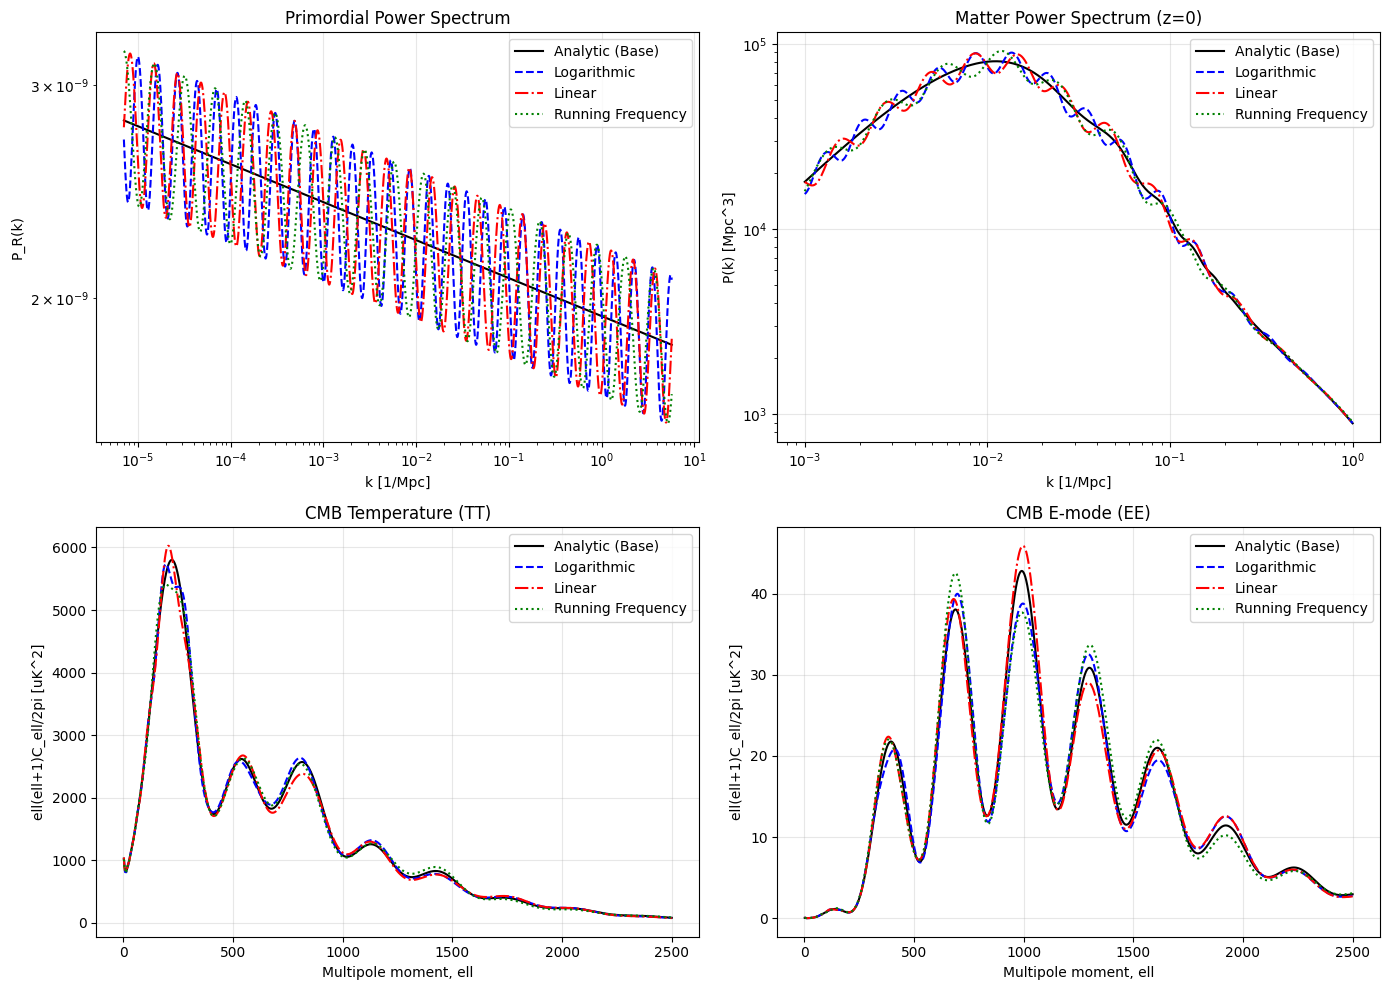

In [5]:
# Group the models for easy looping
models = [
    (cosmo_0, 'Analytic (Base)', 'black', '-'),
    (cosmo_1, 'Logarithmic', 'blue', '--'),
    (cosmo_2, 'Linear', 'red', '-.'),
    (cosmo_3, 'Running Frequency', 'green', ':')
]

# Set up the 2x2 plot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Primordial Power Spectrum (Top Left)
ax[0, 0].set_title('Primordial Power Spectrum')
ax[0, 0].set_xlabel('k [1/Mpc]')
ax[0, 0].set_ylabel('P_R(k)')

# 2. Matter Power Spectrum Today (Top Right)
ax[0, 1].set_title('Matter Power Spectrum (z=0)')
ax[0, 1].set_xlabel('k [1/Mpc]')
ax[0, 1].set_ylabel('P(k) [Mpc^3]')
# Create a k-array based on your P_k_max limit (up to ~1 1/Mpc)
k_m = np.logspace(-3, 0, 400) 

# 3. CMB Temperature TT (Bottom Left)
ax[1, 0].set_title('CMB Temperature (TT)')
ax[1, 0].set_xlabel('Multipole moment, ell')
ax[1, 0].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# 4. CMB E-mode Polarization EE (Bottom Right)
ax[1, 1].set_title('CMB E-mode (EE)')
ax[1, 1].set_xlabel('Multipole moment, ell')
ax[1, 1].set_ylabel('ell(ell+1)C_ell/2pi [uK^2]')

# Extract data and plot for each model
T_cmb_uK = 2.7255e6 # CMB temp in micro-Kelvin

for cosmo, name, color, line in models:
    
    # --- Primordial Power Spectrum ---
    pps = cosmo.get_primordial()
    k_prim = pps['k [1/Mpc]']
    pk_prim = pps['P_scalar(k)']
    ax[0, 0].loglog(k_prim, pk_prim, label=name, color=color, linestyle=line)
    
    # --- Matter Power Spectrum ---
    # cosmo.pk(k, z) evaluates a single k-value, so we loop over the array
    pk_m = np.array([cosmo.pk(k, 0.0) for k in k_m])
    ax[0, 1].loglog(k_m, pk_m, label=name, color=color, linestyle=line)
    
    # --- CMB Spectra ---
    # Extract lensed Cls up to ell=2500
    cls = cosmo.lensed_cl(2500)
    ell = cls['ell'][2:] # Skip ell=0 and 1
    
    # Convert dimensionless Cls to standard uK^2 format
    factor = ell * (ell + 1) / (2 * np.pi) * T_cmb_uK**2
    cl_tt = cls['tt'][2:] * factor
    cl_ee = cls['ee'][2:] * factor
    
    ax[1, 0].plot(ell, cl_tt, label=name, color=color, linestyle=line)
    ax[1, 1].plot(ell, cl_ee, label=name, color=color, linestyle=line)

# Clean up layout and add legends
for axis in ax.flat:
    axis.legend()
    axis.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("global_model_comparison_plots.png", bbox_inches='tight', dpi=300)
plt.show()